## Understanding the Data

### Import python libararies for EDA

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
from wordcloud import WordCloud, STOPWORDS

In [4]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
# Force pandas to display 2 decimal places (no scientific notation)
pd.options.display.float_format = '{:.2f}'.format

### Import the consolidated data into a dataframe for EDA and Cleaning

In [5]:
filepath = '../data/raw/neiss_original_raw_untouched_data.parquet'
#data_original = pd.read_csv(filepath, engine='pyarrow')
data_original = pd.read_parquet(filepath)

In [6]:
# Deep copy to preserve original data
data = data_original.copy()

In [7]:
data.shape

(7315732, 26)

The data has 7 Million observations and 26 features

In [8]:
data.describe()

,data_year,CPSC_Case_Number,Treatment_Date,Age,Sex,Race,Hispanic,Body_Part,Diagnosis,Body_Part_2,Diagnosis_2,Disposition,Location,Fire_Involvement,Product_1,Product_2,Product_3,Alcohol,Drug,PSU,Weight
count,7315732.00,7315732.00,7315732,7315732.00,7315732.00,7315732.00,2031804.00,7315732.00,7315732.00,449039.00,449039.00,7315732.00,7315732.00,7315732.00,7315732.00,7315732.00,7315732.00,2031804.00,2031804.00,7315732.00,7315732.00
mean,2014.28,143889855.69,2014-10-14 00:29:41.551540,43.80,1.45,1.03,1.32,64.72,60.19,65.49,61.03,1.34,2.43,0.01,2126.03,258.59,9.41,0.02,0.02,45.41,37.13
min,2005.00,50100345.00,2005-01-01 00:00:00,0.00,0.00,0.00,0.00,0.00,41.00,0.00,41.00,1.00,0.00,0.00,102.00,0.00,0.00,0.00,0.00,1.00,4.51
25%,2009.00,91212823.75,2009-11-27 00:00:00,12.00,1.00,0.00,0.00,36.00,57.00,35.00,53.00,1.00,0.00,0.00,1211.00,0.00,0.00,0.00,0.00,21.00,14.85
50%,2014.00,140853034.50,2014-08-09 00:00:00,28.00,1.00,1.00,2.00,75.00,59.00,76.00,59.00,1.00,1.00,0.00,1807.00,0.00,0.00,0.00,0.00,41.00,16.84
75%,2019.00,190834617.25,2019-07-27 00:00:00,58.00,2.00,1.00,2.00,82.00,64.00,82.00,68.00,1.00,4.00,0.00,3272.00,0.00,0.00,0.00,0.00,67.00,69.03
max,2024.00,250306332.00,2024-12-31 00:00:00,223.00,2.00,6.00,2.00,94.00,74.00,94.00,74.00,9.00,9.00,3.00,5555.00,5555.00,5555.00,1.00,1.00,207.00,112.17
std,5.70,57090175.52,NaN,49.86,0.50,0.93,0.89,24.02,6.21,22.70,7.16,1.03,3.20,0.15,1352.38,768.44,150.43,0.14,0.15,29.53,29.95


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 26 columns):
 #   Column             Dtype         
---  ------             -----         
 0   data_year          int64         
 1   CPSC_Case_Number   int64         
 2   Treatment_Date     datetime64[us]
 3   Age                int64         
 4   Sex                int64         
 5   Race               int64         
 6   Other_Race         str           
 7   Hispanic           float64       
 8   Body_Part          int64         
 9   Diagnosis          int64         
 10  Other_Diagnosis    str           
 11  Body_Part_2        float64       
 12  Diagnosis_2        float64       
 13  Other_Diagnosis_2  str           
 14  Disposition        int64         
 15  Location           int64         
 16  Fire_Involvement   int64         
 17  Product_1          int64         
 18  Product_2          int64         
 19  Product_3          int64         
 20  Alcohol            float64       
 

#### Observations
1. Need to convert the $Treatment_Date$ field into date time as it is a sring and date manipulations are not easy.
2. Below 5 features are of string type - need to decide if they need to be used for modelling and if yes, need to convert them to numeric fields using encoding. 
3. Derive the feature Hospitalization (Yes or No) based in the Disposition feature.

### Check for nulls data in the dataset

In [10]:
print(data.isnull().sum())

data_year                  0
CPSC_Case_Number           0
Treatment_Date             0
Age                        0
Sex                        0
Race                       0
Other_Race           6821041
Hispanic             5283928
Body_Part                  0
Diagnosis                  0
Other_Diagnosis      6329255
Body_Part_2          6866693
Diagnosis_2          6866693
Other_Diagnosis_2    7214095
Disposition                0
Location                   0
Fire_Involvement           0
Product_1                  0
Product_2                  0
Product_3                  0
Alcohol              5283928
Drug                 5283928
Narrative_1                0
Stratum                    0
PSU                        0
Weight                     0
dtype: int64


#### Observations
Features with NULL values: <br>
1. Other_Race - used only if the Race is 3 - Other.
2. Hispanic - Added from 2019 - reason for NULL.
3. Other Diagnosis - used only if the diagnosis code is 71 - Other/Not stated
4. Body part_2 - Added from 2019 - reason for NULL.
5. Diagnosis_2 - Added from 2019 - reason for NULL.
6. Other Diagnosis_2 - Added from 2019 - reason for NULL.
7. Alcohol - Added from 2019 - reason for NULL.
8. Drug - Added from 2019 - reason for NULL.

####  We need to understand the data in the raw file before performing feature engineering 


### Count of injury data by Year

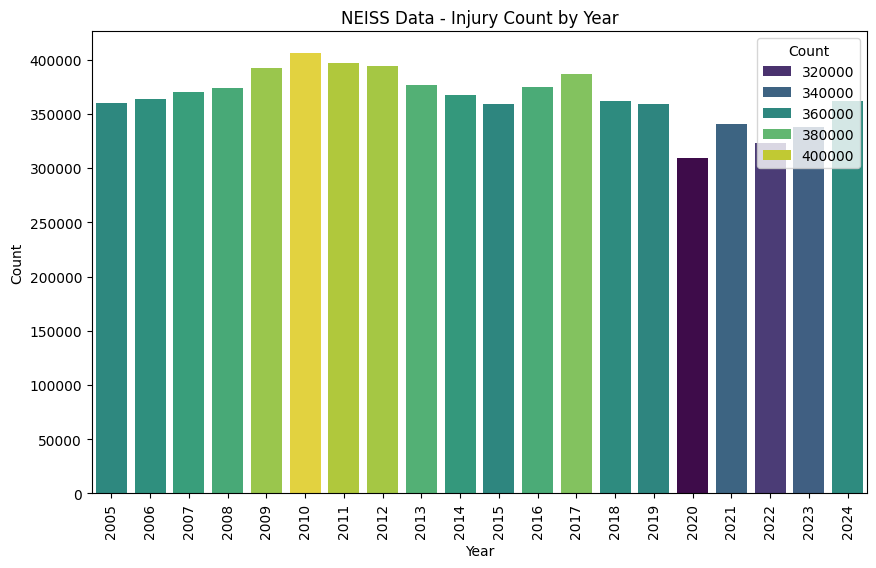

In [11]:
#data['data_year'] = pd.to_datetime(data['data_year'].astype(str), format='%Y')
injury_count_by_year = data.data_year.value_counts(ascending = False).reset_index()
injury_count_by_year.columns = ['Year', 'Count']
injury_count_by_year.sort_values(by='Year', ascending=True, inplace=True)
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Year', data=injury_count_by_year, hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data - Injury Count by Year')
plt.xticks(rotation=90)
plt.show()

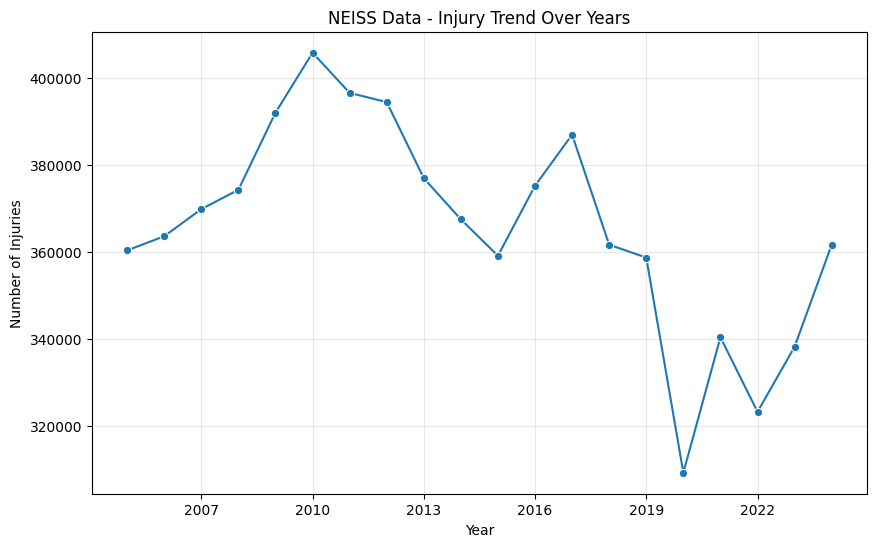

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=injury_count_by_year, x='Year', y='Count', marker='o')
# Force the x-axis to only show integers (prevents "2015.5" labels)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('NEISS Data - Injury Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Injuries')
plt.grid(True, alpha=0.3) # Add a light grid for readability
plt.show()

#### Observations
1. The raw data in the file is kind of modelratly balanced when grouped at year level. <br>
2. There is dip in the injury information between 2019 and and 2022 - may be due to the COVID-19 pandemic and people staying at home - thereby reducing the number of overall injuries.

### Count of Injury data by Month 

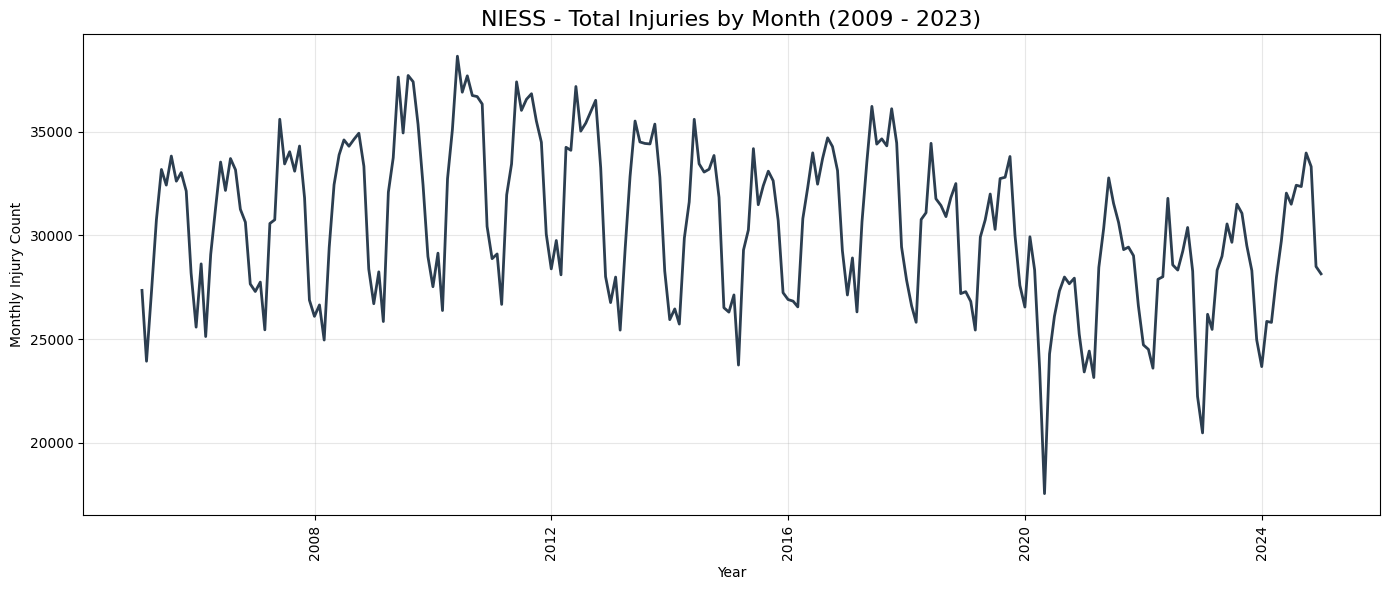

In [13]:
#Convert 'Treatment_Date' to datetime format
data['Treatment_Date'] = pd.to_datetime(data['Treatment_Date'].astype(str), format='%Y-%m-%d')
monthly_injury_counts = data.set_index('Treatment_Date').resample('ME').size().reset_index()
monthly_injury_counts.columns = ['Date', 'Count']
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_injury_counts, x='Date', y='Count', linewidth=2, color='#2c3e50')
ax = plt.gca()
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Add grid and labels
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.title('NIESS - Total Injuries by Month (2009 - 2023)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Monthly Injury Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Observations
1. Seasonal Component - We see a seasonal component in the data for every year. The number of injuries peaks during the summer months and reduces in fall and spring. This could be possibly die to the reduction in mobility and social activities during these months. The only exception to this is seen in the year 2019-2020 where the the overall injury itself has reduced due to an external factor - the COVID 2019 factor. After the pandemic, the rate of injuries has slowely picked up and follows the seasonal trend like before. This shows the impact of external factors/shocks like the pandemic or mobility/economic (fewer people involved in recreational, work or public activities) reasons causing this decrement. The seaconal factor is robust and is predictable.<br>
2. The data exhibits a secoanl cyclicality and declining trend between 2005 to 2011 shows an upward trent in the injury counts where in 2011 it tapers off at 400K. The injury counts shows a slight decline between 2012 -2019 - this could be again due to an external factor like population or increase in the safety awareness contributing to the slight decline. 

The data points to three critical insights: (1) injury rates are heavily dependent on population mobility and economic activity, (2) seasonal factors remain robust and predictable, and (3) exogenous shocks (pandemic, policy changes) can produce sustained structural shifts in injury epidemiology. For public health planning and emergency preparedness, the pre-2020 baseline may no longer reflect current injury risk, and forward projections should account for the new post-pandemic normal.


### Univariate analysis of Injury data by age

In [14]:
data.Age.describe()

count   7315732.00
mean         43.80
std          49.86
min           0.00
25%          12.00
50%          28.00
75%          58.00
max         223.00
Name: Age, dtype: float64

Date need to cleaned/refined as N


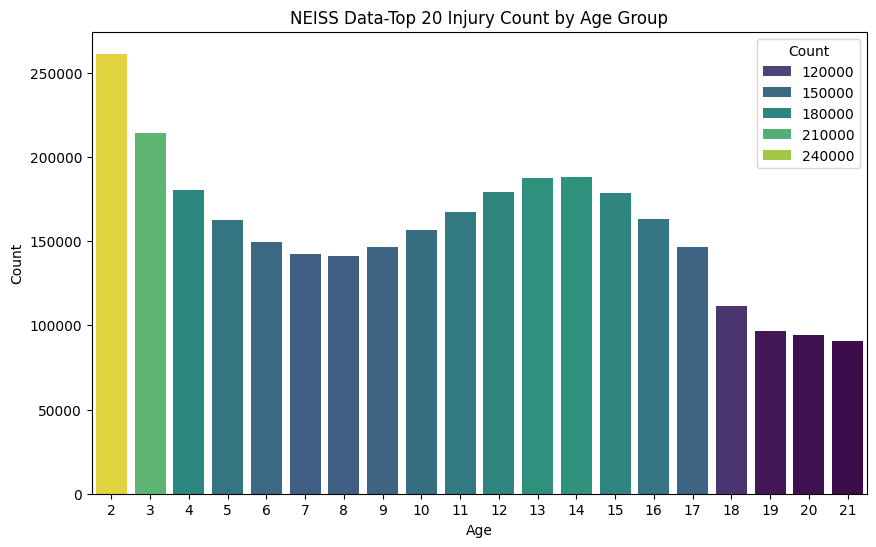

In [15]:
top20_injury_count_by_age = data.Age.value_counts().sort_values(ascending=False).reset_index().head(20)
top20_injury_count_by_age.columns = ['Age', 'Count']
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Age', data=top20_injury_count_by_age , hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data-Top 20 Injury Count by Age Group')
plt.show()

#### Observations:
1. Maximum number of injuries seems to  observed for the age 2 <br>
2. After age 18, the number of injuries seems to stabilize 

### Injury data by Sex

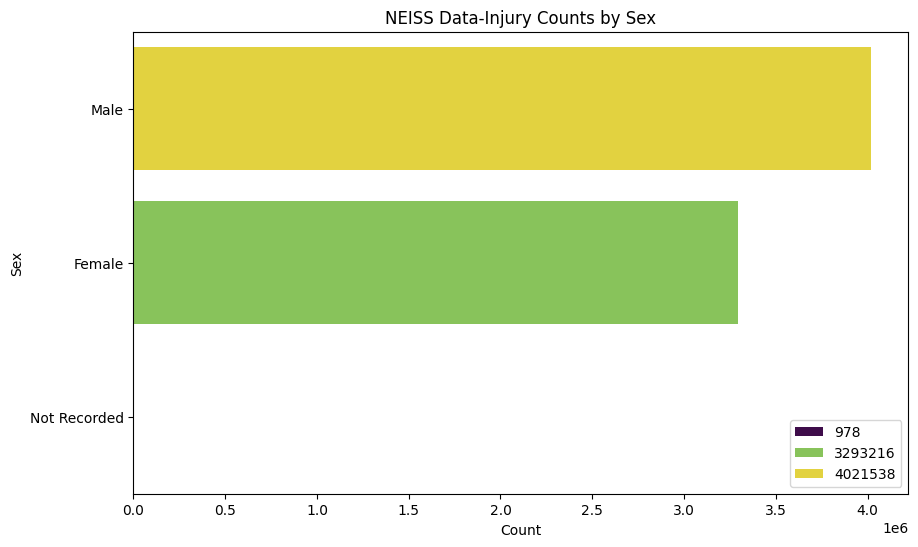

In [16]:
top20_injury_count_by_sex = data.Sex.value_counts().sort_values(ascending=False).reset_index().head(20)
top20_injury_count_by_sex.columns = ['Sex', 'Count']
sex = {0:'Not Recorded',1:'Male',2:'Female',3:'Non Binary/Other'}
plt.figure(figsize=(10,6))
top20_injury_count_by_sex.Sex = top20_injury_count_by_sex.Sex.map(sex)
sns.barplot(x='Count',y='Sex', data=top20_injury_count_by_sex , hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data-Injury Counts by Sex')
plt.legend(loc='lower right')
plt.show()

### Injury data by Race

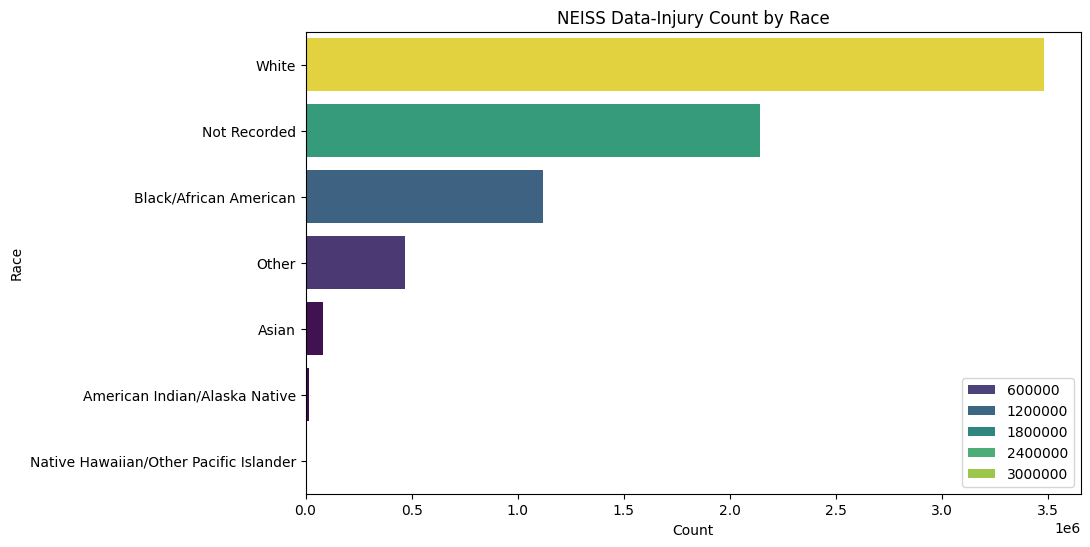

In [17]:
top20_injury_count_by_race = data.Race.value_counts().sort_values(ascending=False).reset_index().head(20)
top20_injury_count_by_race.columns = ['Race', 'Count']
race = {0:'Not Recorded',1:'White',2:'Black/African American',3:'Other',4:'Asian',5:'American Indian/Alaska Native',6:'Native Hawaiian/Other Pacific Islander'}
top20_injury_count_by_race.Race = top20_injury_count_by_race.Race.map(race)
plt.figure(figsize=(10,6))
sns.barplot(x='Count',y='Race', data=top20_injury_count_by_race , hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data-Injury Count by Race')
plt.legend(loc='lower right')
plt.show()

Whites show a high injury rate followed by Not Recorded and Black/Arican Americans

#### Breakdown of Other Race

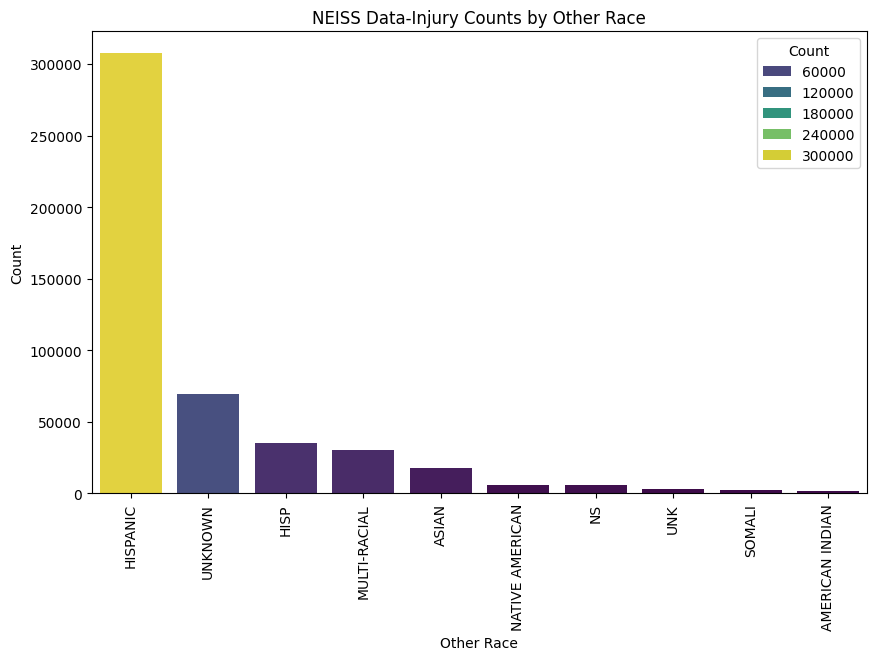

In [18]:
top10_injury_count_by_otherrace= data.Other_Race.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_otherrace.columns = ['Other Race', 'Count']
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Other Race', data=top10_injury_count_by_otherrace , hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data-Injury Counts by Other Race')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.show()

Hispanics show a high injury rate in the 'Other' rate category.

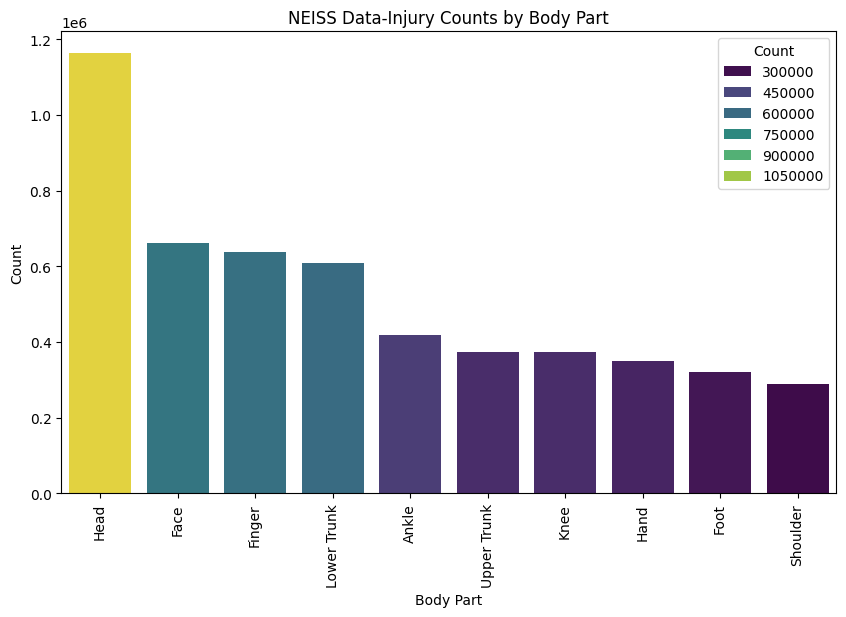

In [19]:
top10_injury_count_by_bodypart= data.Body_Part.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_bodypart.columns = ['Body Part', 'Count']
body_part_map = {
    0: 'Internal',
    30: 'Shoulder',
    31: 'Upper Trunk',
    32: 'Elbow',
    33: 'Lower Arm',
    34: 'Wrist',
    35: 'Knee',
    36: 'Lower Leg',
    37: 'Ankle',
    38: 'Pubic Region',
    75: 'Head',
    76: 'Face',
    77: 'Eyeball',
    79: 'Lower Trunk',
    80: 'Upper Arm',
    81: 'Upper Leg',
    82: 'Hand',
    83: 'Foot',
    84: '25-50pcnt of Body',
    85: 'All Parts Body',
    87: 'Not Stated/Unk',
    88: 'Mouth',
    89: 'Neck',
    92: 'Finger',
    93: 'Toe',
    94: 'Ear'
}

top10_injury_count_by_bodypart['Body Part'] = top10_injury_count_by_bodypart['Body Part'].map(body_part_map)
sort_order = top10_injury_count_by_bodypart['Body Part'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Body Part', data=top10_injury_count_by_bodypart , hue='Count', dodge=False, palette='viridis', order=sort_order)
plt.title('NEISS Data-Injury Counts by Body Part')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.show()

Head injury, followed by Face and Fnger are the most injured body part.

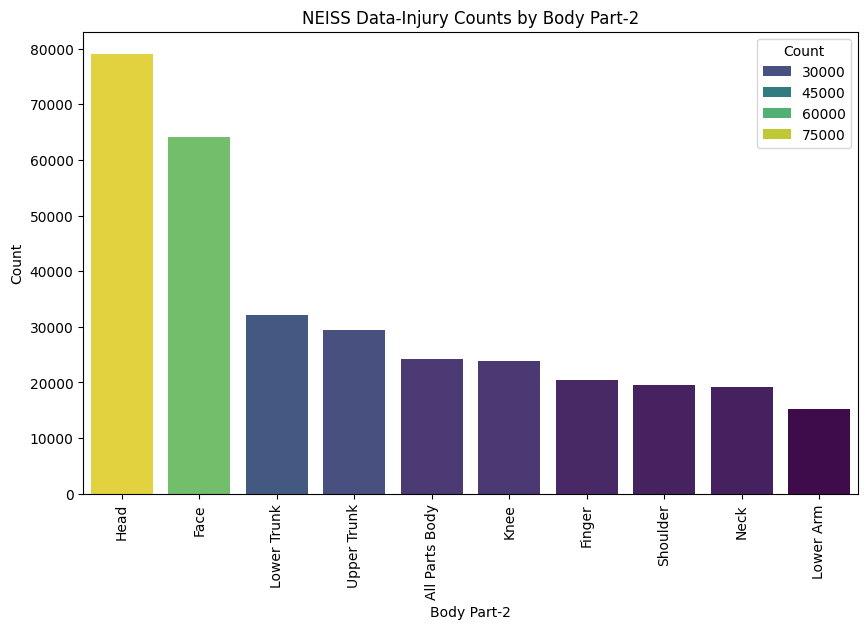

In [20]:

top10_injury_count_by_bodypart2= data.Body_Part_2.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_bodypart2.columns = ['Body Part-2', 'Count']
body_part_map = {
    0: 'Internal',
    30: 'Shoulder',
    31: 'Upper Trunk',
    32: 'Elbow',
    33: 'Lower Arm',
    34: 'Wrist',
    35: 'Knee',
    36: 'Lower Leg',
    37: 'Ankle',
    38: 'Pubic Region',
    75: 'Head',
    76: 'Face',
    77: 'Eyeball',
    79: 'Lower Trunk',
    80: 'Upper Arm',
    81: 'Upper Leg',
    82: 'Hand',
    83: 'Foot',
    84: '25-50pcnt of Body',
    85: 'All Parts Body',
    87: 'Not Stated/Unk',
    88: 'Mouth',
    89: 'Neck',
    92: 'Finger',
    93: 'Toe',
    94: 'Ear'
}
top10_injury_count_by_bodypart2['Body Part-2'] = top10_injury_count_by_bodypart2['Body Part-2'].map(body_part_map)
sort_order = top10_injury_count_by_bodypart2['Body Part-2'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Body Part-2', data=top10_injury_count_by_bodypart2 , hue='Count', dodge=False, palette='viridis', order=sort_order)
plt.title('NEISS Data-Injury Counts by Body Part-2')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.show()

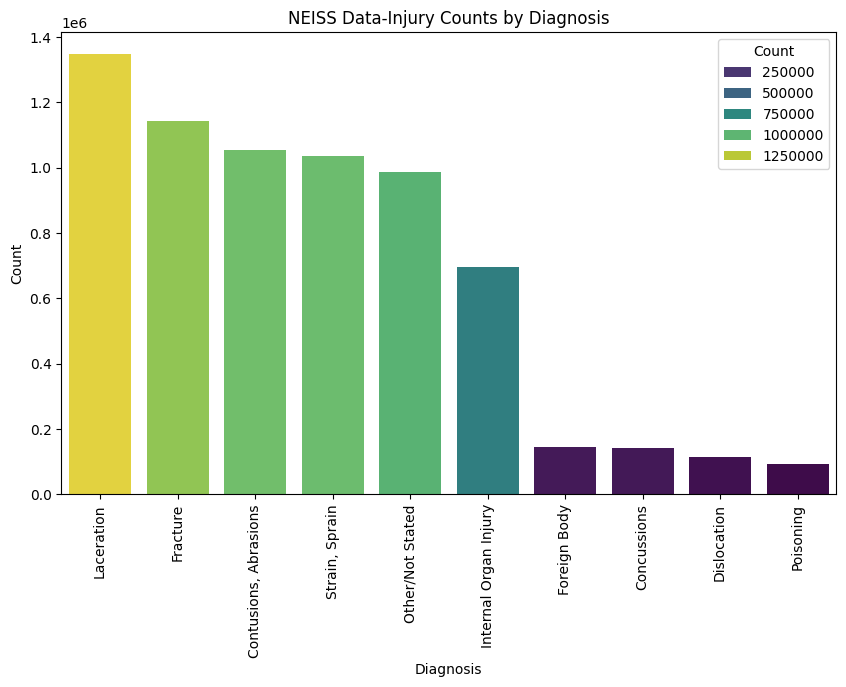

In [21]:

top10_injury_count_by_diagnosis= data.Diagnosis.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_diagnosis.columns = ['Diagnosis', 'Count']
diagnosis_map = {
    41: 'Ingestion',
    42: 'Aspiration',
    46: 'Burns, Electrical',
    47: 'Burns, Not Specified',
    48: 'Burns, Scald',
    49: 'Burns, Chemical',
    50: 'Amputation',
    51: 'Burns, Thermal',
    52: 'Concussions',
    53: 'Contusions, Abrasions',
    54: 'Crushing',
    55: 'Dislocation',
    56: 'Foreign Body',
    57: 'Fracture',
    58: 'Hematoma',
    59: 'Laceration',
    60: 'Dental Injury',
    61: 'Nerve Damage',
    62: 'Internal Organ Injury',
    63: 'Puncture',
    64: 'Strain, Sprain',
    65: 'Anoxia',
    66: 'Hemorrhage',
    67: 'Electric Shock',
    68: 'Poisoning',
    69: 'Submersion',
    71: 'Other/Not Stated',
    72: 'Avulsion',
    73: 'Burns, Radiation',
    74: 'Dermatitis, Conjunctivitis'
}
top10_injury_count_by_diagnosis['Diagnosis'] = top10_injury_count_by_diagnosis['Diagnosis'].map(diagnosis_map)
sort_order = top10_injury_count_by_diagnosis['Diagnosis'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Diagnosis', data=top10_injury_count_by_diagnosis , hue='Count', dodge=False, palette='viridis', order=sort_order)
plt.title('NEISS Data-Injury Counts by Diagnosis')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.show()

Laceration followed by fracture and Contusions account for most of the Injuries.

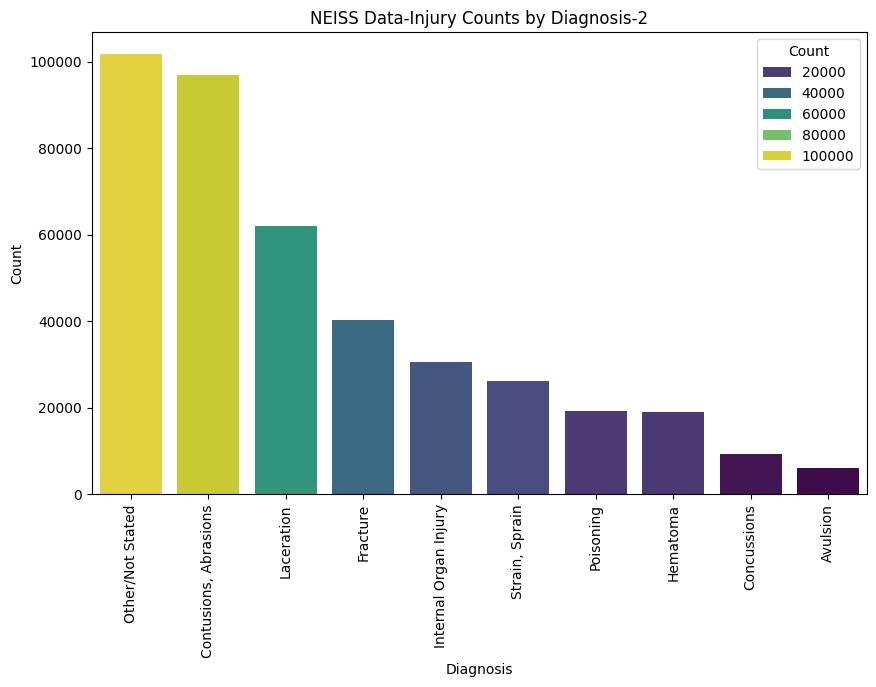

In [22]:

top10_injury_count_by_diagnosis2= data.Diagnosis_2.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_diagnosis2.columns = ['Diagnosis', 'Count']
diagnosis_map = {
    41: 'Ingestion',
    42: 'Aspiration',
    46: 'Burns, Electrical',
    47: 'Burns, Not Specified',
    48: 'Burns, Scald',
    49: 'Burns, Chemical',
    50: 'Amputation',
    51: 'Burns, Thermal',
    52: 'Concussions',
    53: 'Contusions, Abrasions',
    54: 'Crushing',
    55: 'Dislocation',
    56: 'Foreign Body',
    57: 'Fracture',
    58: 'Hematoma',
    59: 'Laceration',
    60: 'Dental Injury',
    61: 'Nerve Damage',
    62: 'Internal Organ Injury',
    63: 'Puncture',
    64: 'Strain, Sprain',
    65: 'Anoxia',
    66: 'Hemorrhage',
    67: 'Electric Shock',
    68: 'Poisoning',
    69: 'Submersion',
    71: 'Other/Not Stated',
    72: 'Avulsion',
    73: 'Burns, Radiation',
    74: 'Dermatitis, Conjunctivitis'
}
top10_injury_count_by_diagnosis2['Diagnosis'] = top10_injury_count_by_diagnosis2['Diagnosis'].map(diagnosis_map)
sort_order = top10_injury_count_by_diagnosis2['Diagnosis'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Diagnosis', data=top10_injury_count_by_diagnosis2 , hue='Count', dodge=False, palette='viridis', order=sort_order)
plt.title('NEISS Data-Injury Counts by Diagnosis-2')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.show()

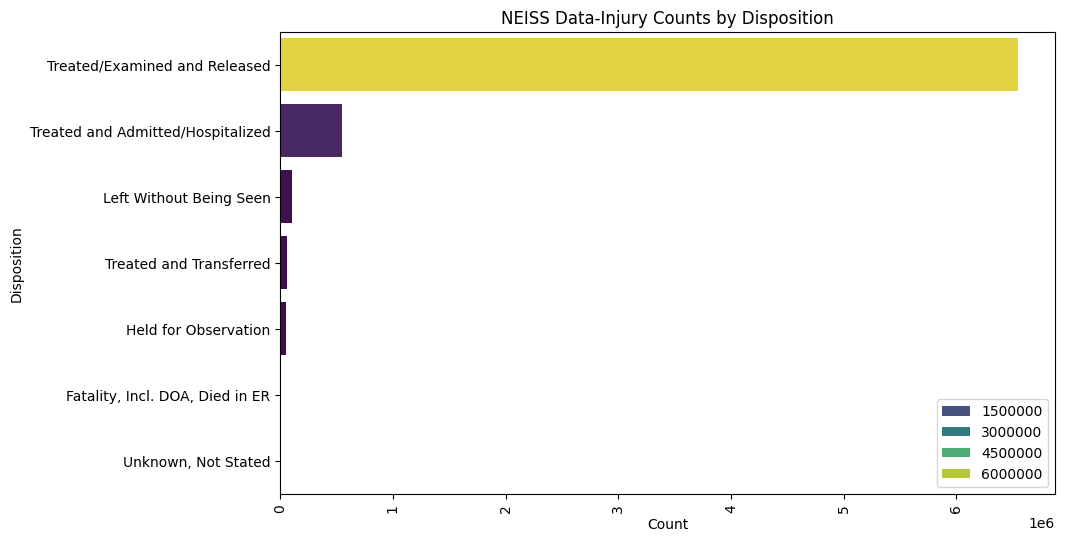

In [23]:

top10_injury_count_by_disposition = data.Disposition.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_disposition.columns = ['Disposition', 'Count']
disposition_map = {
    1: 'Treated/Examined and Released',
    2: 'Treated and Transferred',
    4: 'Treated and Admitted/Hospitalized',
    5: 'Held for Observation',
    6: 'Left Without Being Seen',
    8: 'Fatality, Incl. DOA, Died in ER',
    9: 'Unknown, Not Stated'
}
top10_injury_count_by_disposition['Disposition'] = top10_injury_count_by_disposition['Disposition'].map(disposition_map)
sort_order = top10_injury_count_by_disposition['Disposition'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(x='Count',y='Disposition', data=top10_injury_count_by_disposition, hue='Count', dodge=False, palette='viridis', order=sort_order)
plt.title('NEISS Data-Injury Counts by Disposition')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.legend(loc='lower right')
plt.show()

In [24]:
data_disp= data['Disposition'].value_counts(normalize=True).reset_index()
data_disp.insert(loc=1, column='Disposition_Description', value=data_disp.Disposition.map(disposition_map))
data_disp.columns = ['Disposition_Code', 'Disposition_Description', 'Proportion']
data_disp

,Disposition_Code,Disposition_Description,Proportion
0,1,Treated/Examined and Released,0.90
1,4,Treated and Admitted/Hospitalized,0.08
2,6,Left Without Being Seen,0.01
3,2,Treated and Transferred,0.01
4,5,Held for Observation,0.01
5,8,"Fatality, Incl. DOA, Died in ER",0.00
6,9,"Unknown, Not Stated",0.00


90% of all the Injuries were trearted/examined and released.<br>
7.5% of the Injuries were Admitted/Hospitalized.<br>
Based on the disposition, we need to create a new feature 'Hospitalized' that groups the below dispositions. <br>
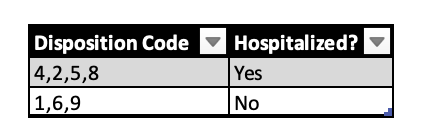

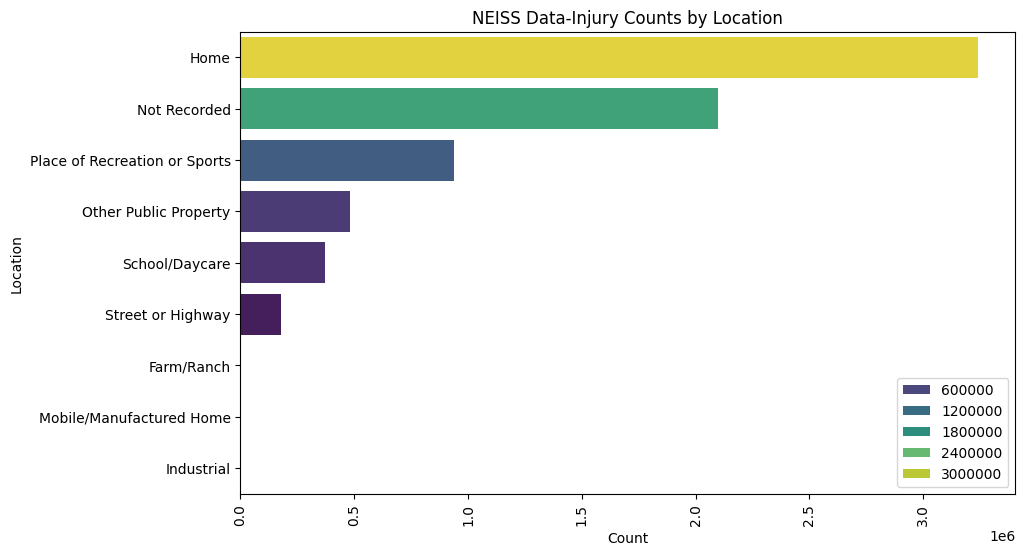

In [25]:

top10_injury_count_by_location = data.Location.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_location.columns = ['Location', 'Count']
location_map = {
    0: 'Not Recorded',
    1: 'Home',
    2: 'Farm/Ranch',
    4: 'Street or Highway',
    5: 'Other Public Property',
    6: 'Mobile/Manufactured Home',
    7: 'Industrial',
    8: 'School/Daycare',
    9: 'Place of Recreation or Sports'
}
top10_injury_count_by_location['Location'] = top10_injury_count_by_location['Location'].map(location_map)
sort_order = top10_injury_count_by_location['Location'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(x='Count',y='Location', data=top10_injury_count_by_location, hue='Count', dodge=False, palette='viridis', order=sort_order)
plt.title('NEISS Data-Injury Counts by Location')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.legend(loc='lower right')
plt.show()

Most of the injuries occured at the Home, followed with Not Recorded, Place of Recreation or at a public property

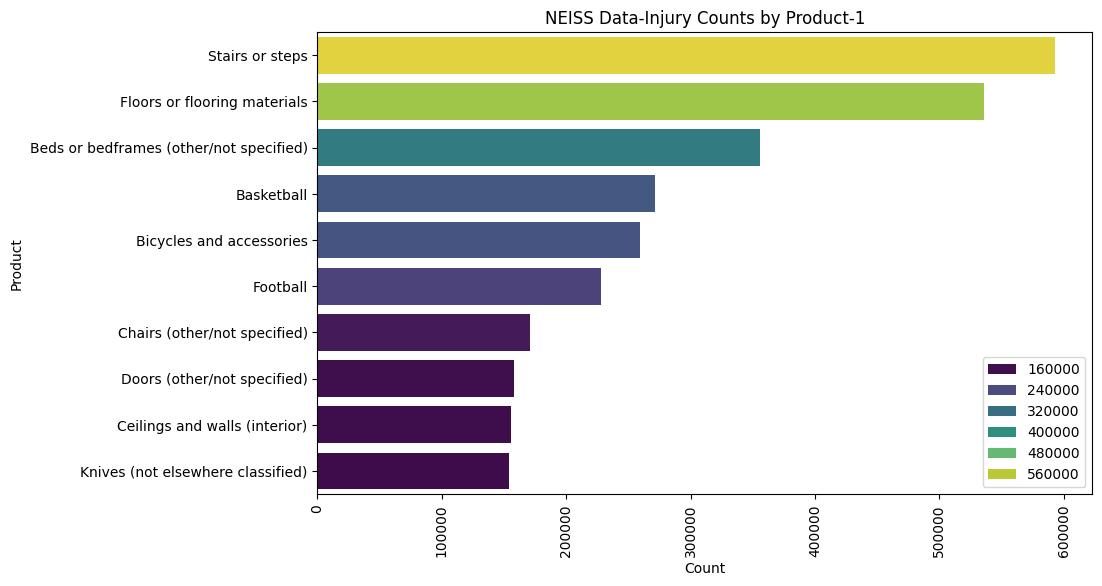

In [26]:

top10_injury_count_by_product1 = data.Product_1.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_product1.columns = ['Product', 'Count']
product_map = {
    1842: 'Stairs or steps',
    1807: 'Floors or flooring materials',
    4076: 'Beds or bedframes (other/not specified)',
    1205: 'Basketball',
    5040: 'Bicycles and accessories',
    1211: 'Football',
    4074: 'Chairs (other/not specified)',
    1893: 'Doors (other/not specified)',
    1884: 'Ceilings and walls (interior)',
    464: 'Knives (not elsewhere classified)'
}
top10_injury_count_by_product1['Product'] = top10_injury_count_by_product1['Product'].map(product_map)
sort_order = top10_injury_count_by_product1['Product'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(x='Count',y='Product', data=top10_injury_count_by_product1, hue='Count', dodge=False, palette='viridis',order=sort_order)
plt.title('NEISS Data-Injury Counts by Product-1')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.legend(loc='lower right')
plt.show()

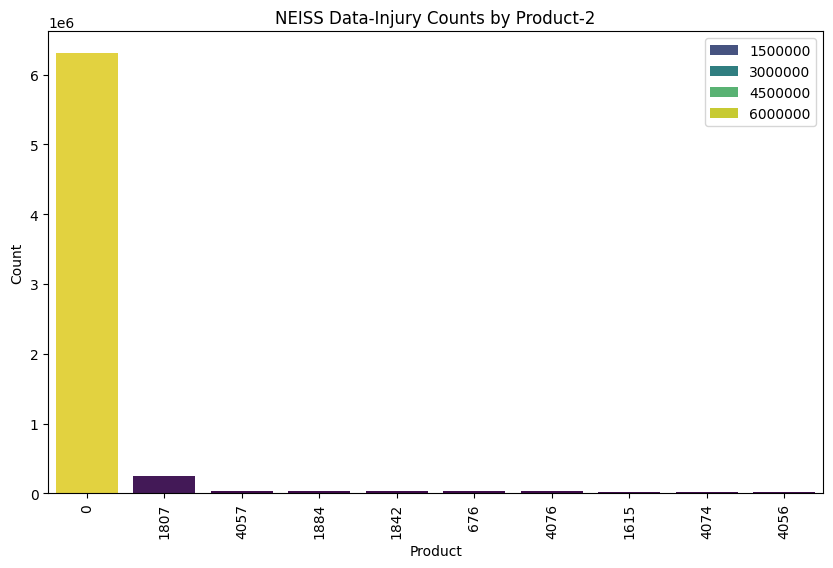

In [27]:

top10_injury_count_by_product2 = data.Product_2.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_product2.columns = ['Product', 'Count']
sort_order = top10_injury_count_by_product2['Product'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Product', data=top10_injury_count_by_product2, hue='Count', dodge=False, palette='viridis',order=sort_order)
plt.title('NEISS Data-Injury Counts by Product-2')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.legend(loc='upper right')
plt.show()

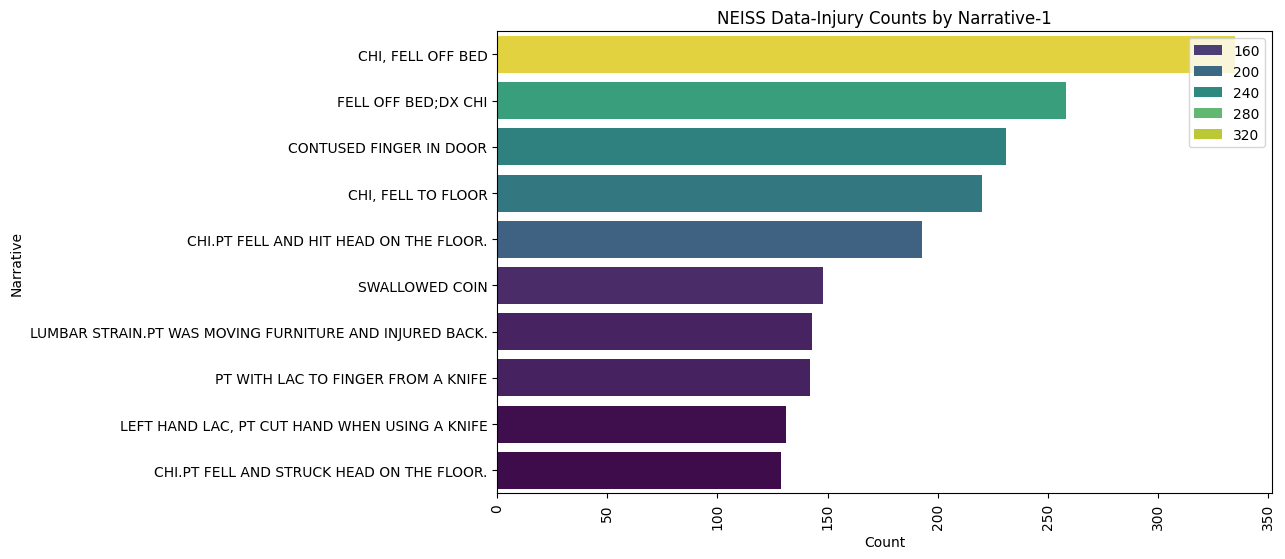

In [28]:

top10_injury_count_by_narrative1 = data.Narrative_1.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_narrative1.columns = ['Narrative', 'Count']
sort_order = top10_injury_count_by_narrative1['Narrative'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(x='Count',y='Narrative', data=top10_injury_count_by_narrative1, hue='Count', dodge=False, palette='viridis',order=sort_order)
plt.title('NEISS Data-Injury Counts by Narrative-1')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.legend(loc='upper right')
plt.show()

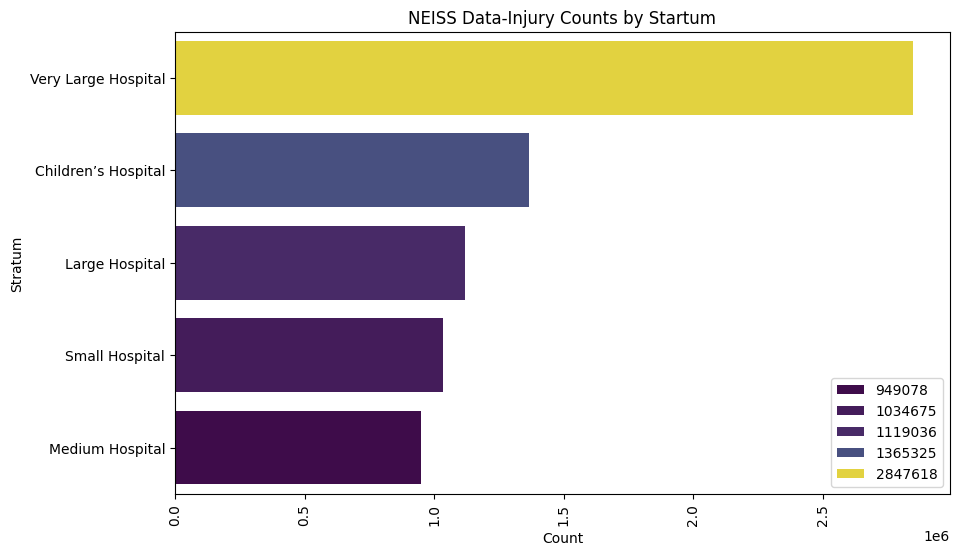

In [29]:

top10_injury_count_by_stratum = data.Stratum.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_stratum.columns = ['Stratum', 'Count']
stratum_map = {
    'C': 'Children’s Hospital',
    'S': 'Small Hospital',
    'M': 'Medium Hospital',
    'L': 'Large Hospital',
    'V': 'Very Large Hospital'
}
top10_injury_count_by_stratum['Stratum'] = top10_injury_count_by_stratum['Stratum'].map(stratum_map)
sort_order = top10_injury_count_by_stratum['Stratum'].tolist()

plt.figure(figsize=(10,6))
sns.barplot(x='Count',y='Stratum', data=top10_injury_count_by_stratum, hue='Count', dodge=False, palette='viridis',order=sort_order)
plt.title('NEISS Data-Injury Counts by Startum')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.legend(loc='lower right')
plt.show()

#### WordCloud for Narrative Feature

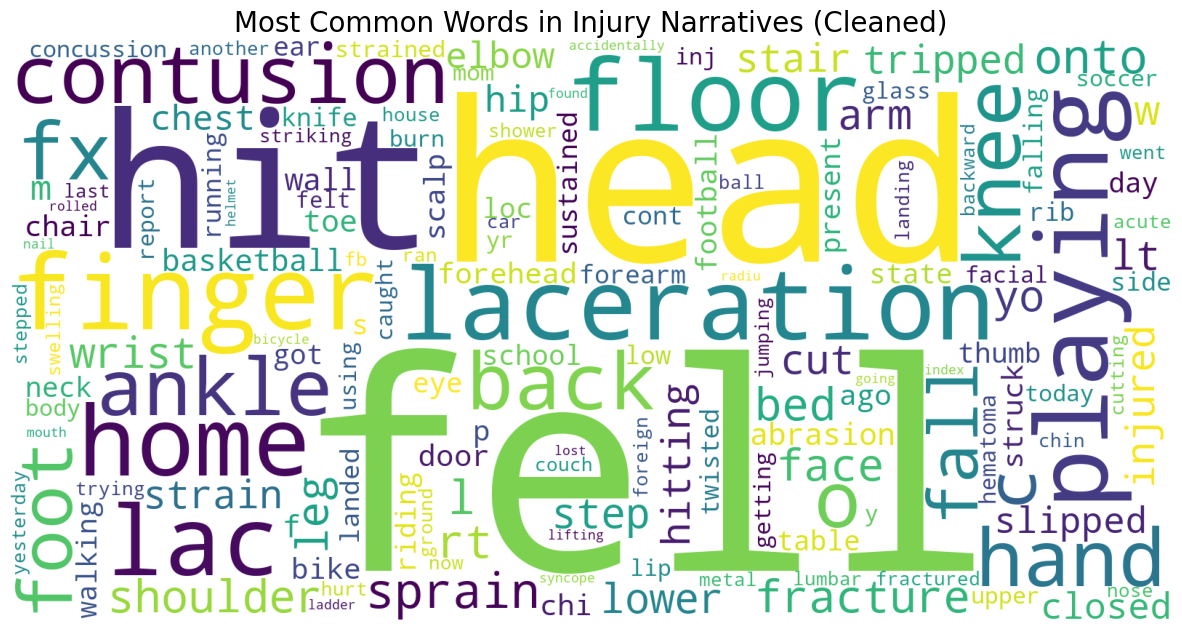

In [ ]:
# We add standard English words ('the', 'and') + NEISS jargon
custom_stopwords = set(STOPWORDS)
neiss_jargon = {
    'pt', 'patient', 'yom', 'yof', 'dx', 'diagnosis', 'stated', 
    'year', 'old', 'male', 'female', 'left', 'right', 'sustain', 
    'injury', 'pain', 'hospital', 'emergency', 'dept', 'er', 'b', 'fx'
}
custom_stopwords.update(neiss_jargon)
# We drop NA values and convert to lowercase to ensure 'Ladder' == 'ladder'
text_data = " ".join(data['Narrative_1'].dropna().astype(str)).lower()
# 3. Generate the WordCloud
wordcloud = WordCloud(
    width=1600, 
    height=800,
    background_color='white',
    stopwords=custom_stopwords,
    min_font_size=10,
    max_words=150,
    collocations=False  # Set to True if you want phrases like "fell off"
).generate(text_data)
# 4. Display the Plot
plt.figure(figsize=(15, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")  # Removes the x/y axis numbers
plt.title('Most Common Words in Injury Narratives (Cleaned)', fontsize=20)
plt.show()

Most common injury narratives are Head, hit, fell/fall, playing, laceration,. 